Mortgage Default Risk Prediction Using Machine Learning
### Freddie Mac Single-Family Loan-Level Dataset (2015 Vintage)
**Team 19:** Pranav Waghmare, Atish Khune

## 1.Data Loading and Initial Inspection

In [1]:
import pandas as pd

# Read just the first 5 rows to see what the raw data looks like
orig_peek = pd.read_csv('data/sample_orig_2015.txt', sep='|', header=None, nrows=5)

print("Shape:", orig_peek.shape)
print("Number of columns:", orig_peek.shape[1])
orig_peek

Shape: (5, 32)
Number of columns: 32


,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
0,734,201504,N,203003,NaN,0,1,P,80,15,...,2,Other sellers,U.S. BANK N.A.,NaN,NaN,9,NaN,7,N,7
1,797,201504,N,204503,NaN,0,1,S,37,26,...,2,Other sellers,Other servicers,NaN,NaN,9,NaN,7,N,7
2,670,201504,N,203003,11460.0,12,1,P,90,33,...,2,Other sellers,Other servicers,NaN,NaN,9,NaN,7,N,N
3,731,201503,N,204502,NaN,0,1,I,73,999,...,2,Other sellers,Other servicers,NaN,A07Q20031002,9,Y,7,N,7
4,668,201504,N,203003,39340.0,0,2,I,75,30,...,2,Other sellers,NATIONSTAR MORTGAGE LLC DBA MR. COOPER,NaN,NaN,9,NaN,7,N,7


In [2]:
# Read the first 10 rows of the performance file to check its structure
perf_peek = pd.read_csv('data/sample_svcg_2015.txt', sep='|', header=None, nrows=10)

print("Shape:", perf_peek.shape)
print("Number of columns:", perf_peek.shape[1])
perf_peek

Shape: (10, 32)
Number of columns: 32


,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
0,F15Q10000025,201503,417000.00,0,0,180,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,417000.00
1,F15Q10000025,201504,415000.00,0,1,179,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,415000.00
2,F15Q10000025,201505,413000.00,0,2,178,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,413000.00
3,F15Q10000025,201506,409000.00,0,3,177,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,409000.00
4,F15Q10000025,201507,409000.00,0,4,176,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,409000.00
5,F15Q10000025,201508,407000.00,0,5,175,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,407000.00
6,F15Q10000025,201509,405000.00,0,6,174,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,405000.00
7,F15Q10000025,201510,401173.07,0,7,173,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,401173.07
8,F15Q10000025,201511,399228.34,0,8,172,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,399228.34
9,F15Q10000025,201512,397279.56,0,9,171,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,397279.56


## 2. Column Naming and Schema Mapping

In [3]:
import pandas as pd

# Column names for origination file (from Freddie Mac User Guide pages 5-10)
orig_columns = [
    'credit_score', 'first_payment_date', 'first_time_buyer', 'maturity_date',
    'msa', 'mi_pct', 'num_units', 'occupancy_status', 'orig_cltv', 'orig_dti',
    'orig_upb', 'orig_ltv', 'orig_interest_rate', 'channel', 'ppm_flag',
    'amortization_type', 'property_state', 'property_type', 'postal_code',
    'loan_seq_no', 'loan_purpose', 'orig_loan_term', 'num_borrowers',
    'seller_name', 'servicer_name', 'super_conforming', 'pre_relief_refi_seq',
    'special_elig_program', 'relief_refi_indicator', 'property_val_method',
    'io_indicator', 'mi_cancel_indicator'
]

# Column names for monthly performance file (from User Guide pages 10-14)
perf_columns = [
    'loan_seq_no', 'monthly_rpt_period', 'current_upb', 'delinquency_status',
    'loan_age', 'remaining_months', 'defect_settlement_date', 'modification_flag',
    'zero_balance_code', 'zero_balance_eff_date', 'current_interest_rate',
    'current_non_int_upb', 'ddlpi', 'mi_recoveries', 'net_sale_proceeds',
    'non_mi_recoveries', 'total_expenses', 'legal_costs', 'maint_preserv_costs',
    'taxes_insurance', 'misc_expenses', 'actual_loss', 'cumulative_mod_cost',
    'interest_rate_step', 'payment_deferral', 'eltv', 'zero_balance_removal_upb',
    'delinq_accrued_interest', 'delinq_disaster', 'borrower_assist_status',
    'current_month_mod_cost', 'interest_bearing_upb'
]

# Load both files with the column names we defined above
orig = pd.read_csv('data/sample_orig_2015.txt', sep='|', header=None, names=orig_columns, low_memory=False)
perf = pd.read_csv('data/sample_svcg_2015.txt', sep='|', header=None, names=perf_columns, low_memory=False)

print("Origination file:", orig.shape)
print("Performance file:", perf.shape)

Origination file: (50000, 32)
Performance file: (3396519, 32)


## 3. Data Quality Assessment

In [4]:
#Check the structure of the origination file
orig.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 32 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   credit_score           50000 non-null  int64  
 1   first_payment_date     50000 non-null  int64  
 2   first_time_buyer       50000 non-null  object 
 3   maturity_date          50000 non-null  int64  
 4   msa                    44396 non-null  float64
 5   mi_pct                 50000 non-null  int64  
 6   num_units              50000 non-null  int64  
 7   occupancy_status       50000 non-null  object 
 8   orig_cltv              50000 non-null  int64  
 9   orig_dti               50000 non-null  int64  
 10  orig_upb               50000 non-null  int64  
 11  orig_ltv               50000 non-null  int64  
 12  orig_interest_rate     50000 non-null  float64
 13  channel                50000 non-null  object 
 14  ppm_flag               50000 non-null  object 
 15  am

In [5]:
# Statistical summary of numeric columns
orig.describe()

,credit_score,first_payment_date,maturity_date,msa,mi_pct,num_units,orig_cltv,orig_dti,orig_upb,orig_ltv,orig_interest_rate,postal_code,orig_loan_term,num_borrowers,property_val_method
count,50000.000000,50000.000000,50000.000000,44396.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.0
mean,749.758940,201522.812300,204142.713360,30277.954050,5.901860,1.031100,74.420920,111.437720,224006.060000,73.52848,3.974625,56248.376000,315.294020,1.510800,7.0
std,47.508044,34.953772,633.581747,11259.893959,11.149558,0.235487,18.488844,262.595519,119990.497697,17.99667,0.451811,29957.963198,75.922712,0.499888,0.0
min,462.000000,201502.000000,202307.000000,10180.000000,0.000000,1.000000,5.000000,1.000000,10000.000000,5.00000,2.375000,700.000000,96.000000,1.000000,7.0
25%,718.000000,201506.000000,203511.000000,19430.000000,0.000000,1.000000,66.000000,28.000000,131000.000000,65.00000,3.750000,30300.000000,240.000000,1.000000,7.0
50%,760.000000,201509.000000,204505.000000,31540.000000,0.000000,1.000000,79.000000,36.000000,200000.000000,78.00000,4.000000,55800.000000,360.000000,2.000000,7.0
75%,788.000000,201512.000000,204509.000000,39900.000000,0.000000,1.000000,85.000000,43.000000,299000.000000,83.00000,4.250000,85100.000000,360.000000,2.000000,7.0
max,834.000000,202004.000000,204704.000000,49740.000000,40.000000,4.000000,999.000000,999.000000,974000.000000,999.00000,5.500000,99900.000000,366.000000,2.000000,7.0


## 4. Sentinel Value Detection and Cleaning

In [6]:
# Check how many loans have sentinel "Not Available" values in key columns

print("credit_score = 9999:", (orig['credit_score'] == 9999).sum())
print("orig_cltv = 999:   ", (orig['orig_cltv'] == 999).sum())
print("orig_dti = 999:    ", (orig['orig_dti'] == 999).sum())
print("orig_ltv = 999:    ", (orig['orig_ltv'] == 999).sum())
print("mi_pct = 999:      ", (orig['mi_pct'] == 999).sum())
print("num_units = 99:    ", (orig['num_units'] == 99).sum())
print("num_borrowers = 99:", (orig['num_borrowers'] == 99).sum())

print("\nTotal loans:", len(orig))

credit_score = 9999: 0
orig_cltv = 999:    1
orig_dti = 999:     4020
orig_ltv = 999:     1
mi_pct = 999:       0
num_units = 99:     0
num_borrowers = 99: 0

Total loans: 50000


In [7]:
# Looking at the distribution of important categorical columns
cat_cols = ['first_time_buyer', 'occupancy_status', 'channel', 'loan_purpose', 
            'property_type', 'amortization_type', 'ppm_flag', 'io_indicator']

for col in cat_cols:
    print(col)
    print(orig[col].value_counts())
    print()

first_time_buyer
first_time_buyer
N    42202
Y     7790
9        8
Name: count, dtype: int64

occupancy_status
occupancy_status
P    44096
I     4156
S     1748
Name: count, dtype: int64

channel
channel
R    30430
C    14616
B     4954
Name: count, dtype: int64

loan_purpose
loan_purpose
P    22154
N    17513
C    10333
Name: count, dtype: int64

property_type
property_type
SF    32566
PU    13149
CO     4012
MH      176
CP       97
Name: count, dtype: int64

amortization_type
amortization_type
FRM    50000
Name: count, dtype: int64

ppm_flag
ppm_flag
N    50000
Name: count, dtype: int64

io_indicator
io_indicator
N    50000
Name: count, dtype: int64



In [8]:
perf.columns

Index(['loan_seq_no', 'monthly_rpt_period', 'current_upb',
       'delinquency_status', 'loan_age', 'remaining_months',
       'defect_settlement_date', 'modification_flag', 'zero_balance_code',
       'zero_balance_eff_date', 'current_interest_rate', 'current_non_int_upb',
       'ddlpi', 'mi_recoveries', 'net_sale_proceeds', 'non_mi_recoveries',
       'total_expenses', 'legal_costs', 'maint_preserv_costs',
       'taxes_insurance', 'misc_expenses', 'actual_loss',
       'cumulative_mod_cost', 'interest_rate_step', 'payment_deferral', 'eltv',
       'zero_balance_removal_upb', 'delinq_accrued_interest',
       'delinq_disaster', 'borrower_assist_status', 'current_month_mod_cost',
       'interest_bearing_upb'],
      dtype='object')

## 5. Exploratory Data Analysis
### 5.1 Delinquency Status and Target Variable

In [9]:
print("Data type:", perf['delinquency_status'].dtype)
print("\nUnique values:")
print(sorted(perf['delinquency_status'].unique()))

Data type: object

Unique values:
['0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '4', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '5', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '6', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '7', '70', '8', '9', 'RA']


In [ ]:
# Clean the delinquency_status column

perf['delinquency_status'] = perf['delinquency_status'].astype(str).str.strip()

print("Delinquency status value counts (top 15):")
print(perf['delinquency_status'].value_counts().head(15))
print("\nUnique values:", perf['delinquency_status'].nunique())

Delinquency status value counts (top 15):
delinquency_status
0     3346020
1       22821
2        6501
3        3677
4        2548
5        2105
6        1623
7        1395
8        1158
9        1007
10        909
11        824
12        736
13        627
RA        567
Name: count, dtype: int64

Unique values: 72


In [11]:
# Find the worst (max) delinquency each loan ever reached
# 'RA' means REO Acquisition — replace it with 999 so it counts as the most severe

perf['delinq_numeric'] = pd.to_numeric(
    perf['delinquency_status'].replace('RA', '999')
)

worst_delinq = perf.groupby('loan_seq_no')['delinq_numeric'].max()

# Define default as reaching 90+ days delinquent (status >= 3)
total_loans = worst_delinq.shape[0]
defaulted_loans = (worst_delinq >= 3).sum()
default_rate = defaulted_loans / total_loans * 100

print("Total unique loans:", total_loans)
print("Loans reaching 90+ days delinquent:", defaulted_loans)
print("Default rate: {:.2f}%".format(default_rate))

print("\nWorst delinquency distribution:")
print("  Never late (0):       ", (worst_delinq == 0).sum())
print("  Worst was 30-day (1): ", (worst_delinq == 1).sum())
print("  Worst was 60-day (2): ", (worst_delinq == 2).sum())
print("  Reached 90+ days (3+):", (worst_delinq >= 3).sum())

Total unique loans: 50000
Loans reaching 90+ days delinquent: 2032
Default rate: 4.06%

Worst delinquency distribution:
  Never late (0):        43436
  Worst was 30-day (1):  3873
  Worst was 60-day (2):  659
  Reached 90+ days (3+): 2032


## 6. Target Variable Construction

In [12]:
# Build the target variable with a clean time split to avoid data leakage
# We only look at months 0-11 for features, and months 12+ to define default

perf_future = perf[perf['loan_age'] >= 12].copy()

worst_delinq_future = perf_future.groupby('loan_seq_no')['delinq_numeric'].max()

target_future = (worst_delinq_future >= 3).astype(int).reset_index()
target_future.columns = ['loan_seq_no', 'default_flag']

all_loans = pd.DataFrame({'loan_seq_no': orig['loan_seq_no'].unique()})
target = all_loans.merge(target_future, on='loan_seq_no', how='left')
target['default_flag'] = target['default_flag'].fillna(0).astype(int)

model_df = orig.merge(target, on='loan_seq_no', how='inner')

print("Total loans:", len(target))
print(target['default_flag'].value_counts())
print("Default rate: {:.2f}%".format(target['default_flag'].mean() * 100))

Total loans: 50000
default_flag
0    47976
1     2024
Name: count, dtype: int64
Default rate: 4.05%


In [13]:
# Check the zero balance codes to understand how loans terminated
# Each loan has multiple monthly records, but zero balance code only shows up at the end

last_records = perf.groupby('loan_seq_no').agg(
    worst_delinq=('delinq_numeric', 'max'),
    zero_balance_code=('zero_balance_code', 'last')
).reset_index()

merged_check = last_records.merge(target, on='loan_seq_no')

# See what happened to defaulted vs non-defaulted loans
print("Zero balance codes for DEFAULTED loans:")
print(merged_check[merged_check['default_flag'] == 1]['zero_balance_code'].value_counts(dropna=False))

print("\nZero balance codes for NON-DEFAULTED loans:")
print(merged_check[merged_check['default_flag'] == 0]['zero_balance_code'].value_counts(dropna=False).head(10))

Zero balance codes for DEFAULTED loans:
zero_balance_code
1.0     922
NaN     861
16.0    102
9.0      55
2.0      45
15.0     18
3.0      17
96.0      4
Name: count, dtype: int64

Zero balance codes for NON-DEFAULTED loans:
zero_balance_code
1.0     36824
NaN     11115
96.0       31
16.0        5
3.0         1
Name: count, dtype: int64


### Column Selection for Modeling

In [ ]:
# Drop columns that won't help with modeling

cols_to_drop = [
    'amortization_type', 'ppm_flag', 'io_indicator', 'property_val_method',
    'loan_seq_no', 'first_payment_date', 'maturity_date',
    'pre_relief_refi_seq', 'seller_name', 'servicer_name'
]

loan_ids = model_df['loan_seq_no'].copy()

model_clean = model_df.drop(columns=cols_to_drop)

print("Before:", model_df.shape[1], "columns")
print("After:", model_clean.shape[1], "columns")
print("\nRemaining columns:", list(model_clean.columns))

Before: 33 columns
After: 23 columns

Remaining columns: ['credit_score', 'first_time_buyer', 'msa', 'mi_pct', 'num_units', 'occupancy_status', 'orig_cltv', 'orig_dti', 'orig_upb', 'orig_ltv', 'orig_interest_rate', 'channel', 'property_state', 'property_type', 'postal_code', 'loan_purpose', 'orig_loan_term', 'num_borrowers', 'super_conforming', 'special_elig_program', 'relief_refi_indicator', 'mi_cancel_indicator', 'default_flag']


In [15]:
import numpy as np

# Replace Freddie Mac's "Not Available" codes with NaN so they show up as actual missing values
# These sentinel codes are documented in the User Guide

model_clean['credit_score'] = model_clean['credit_score'].replace(9999, np.nan)
model_clean['orig_cltv'] = model_clean['orig_cltv'].replace(999, np.nan)
model_clean['orig_dti'] = model_clean['orig_dti'].replace(999, np.nan)
model_clean['orig_ltv'] = model_clean['orig_ltv'].replace(999, np.nan)
model_clean['mi_pct'] = model_clean['mi_pct'].replace(999, np.nan)
model_clean['num_units'] = model_clean['num_units'].replace(99, np.nan)
model_clean['num_borrowers'] = model_clean['num_borrowers'].replace(99, np.nan)

model_clean['first_time_buyer'] = model_clean['first_time_buyer'].replace('9', np.nan)
model_clean['occupancy_status'] = model_clean['occupancy_status'].replace('9', np.nan)
model_clean['channel'] = model_clean['channel'].replace('9', np.nan)
model_clean['special_elig_program'] = model_clean['special_elig_program'].replace('9', np.nan)

# Check the actual missing values now
missing = model_clean.isnull().sum()
missing_pct = (missing / len(model_clean) * 100).round(2)

missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
print(missing_df[missing_df['missing_count'] > 0].sort_values('missing_pct', ascending=False))
print("\nTotal rows:", len(model_clean))

                       missing_count  missing_pct
special_elig_program           49675        99.35
super_conforming               47960        95.92
relief_refi_indicator          45983        91.97
msa                             5604        11.21
orig_dti                        4020         8.04
first_time_buyer                   8         0.02
orig_cltv                          1         0.00
orig_ltv                           1         0.00

Total rows: 50000


### Handling Heavily-Missing Columns

In [16]:
# Drop special_elig_program since it's 99% missing
model_clean = model_clean.drop(columns=['special_elig_program'])

# Convert super_conforming and relief_refi_indicator to 0/1 (NaN treated as 0)
model_clean['super_conforming'] = model_clean['super_conforming'].apply(lambda x: 1 if x == 'Y' else 0)
model_clean['relief_refi_indicator'] = model_clean['relief_refi_indicator'].apply(lambda x: 1 if x == 'Y' else 0)

print("Shape after cleanup:", model_clean.shape)

print("\nsuper_conforming:")
print(model_clean['super_conforming'].value_counts())
print("\nrelief_refi_indicator:")
print(model_clean['relief_refi_indicator'].value_counts())

# Check what's still missing
missing = model_clean.isnull().sum()
missing_pct = (missing / len(model_clean) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
print("\nRemaining missing values:")
print(missing_df[missing_df['missing_count'] > 0].sort_values('missing_pct', ascending=False))

Shape after cleanup: (50000, 22)

super_conforming:
super_conforming
0    47960
1     2040
Name: count, dtype: int64

relief_refi_indicator:
relief_refi_indicator
0    45983
1     4017
Name: count, dtype: int64

Remaining missing values:
                  missing_count  missing_pct
msa                        5604        11.21
orig_dti                   4020         8.04
first_time_buyer              8         0.02
orig_cltv                     1         0.00
orig_ltv                      1         0.00


### 5.2 Feature Distributions by Default Status

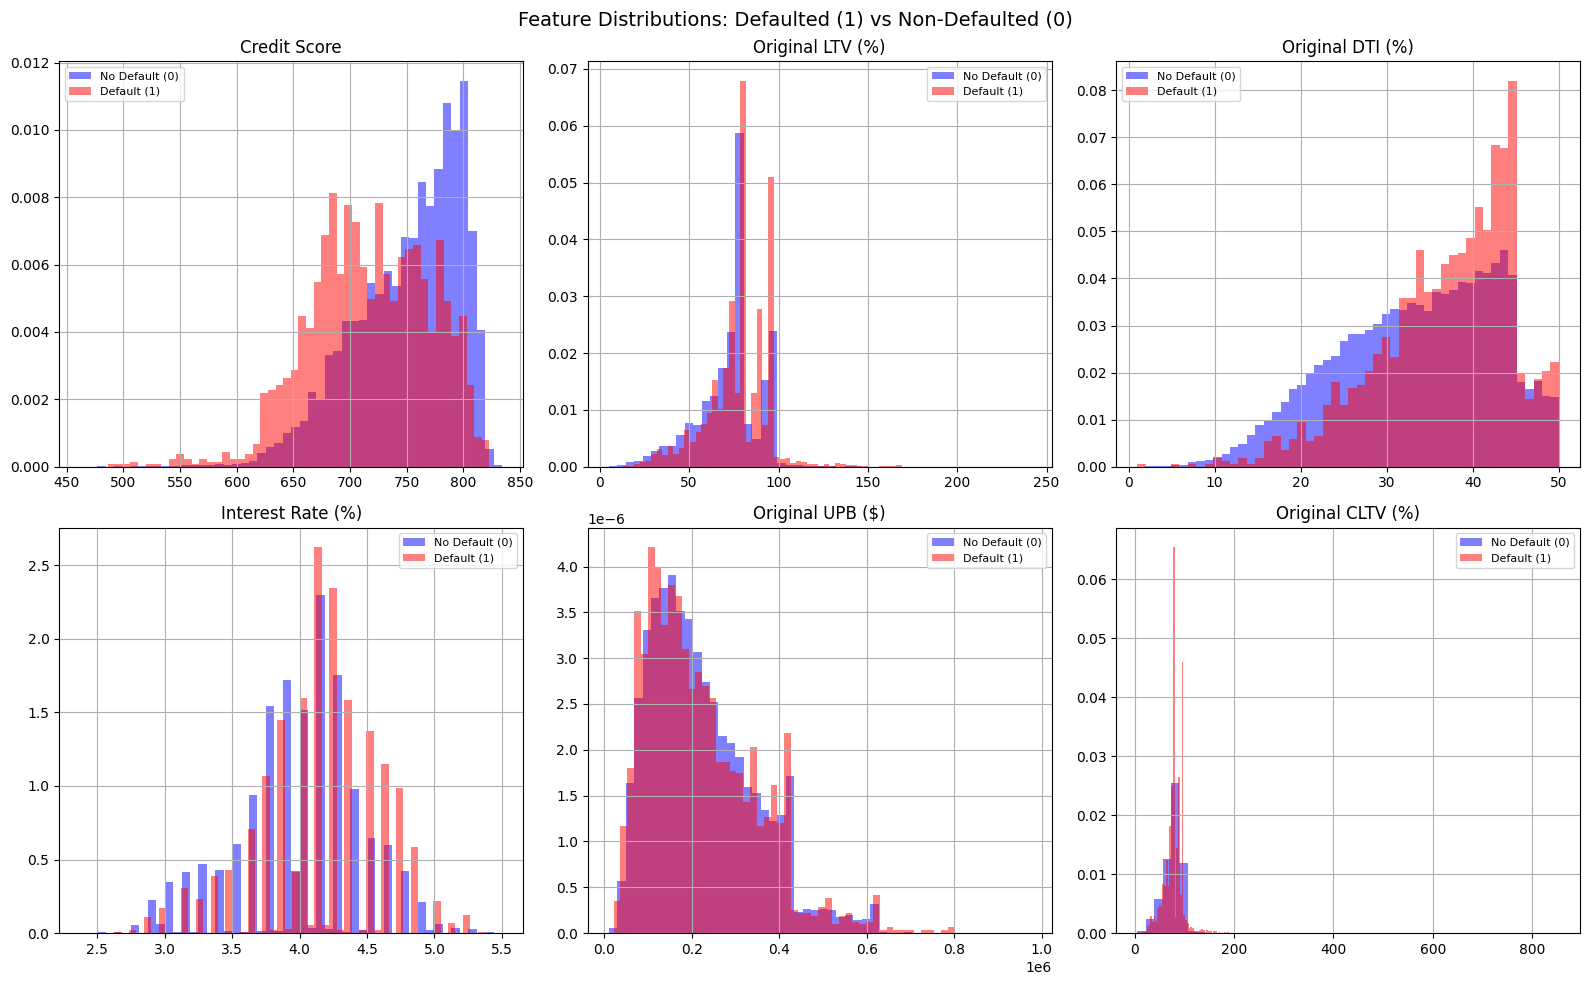

In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Feature Distributions: Defaulted (1) vs Non-Defaulted (0)', fontsize=14)

features_to_plot = [
    ('credit_score', 'Credit Score'),
    ('orig_ltv', 'Original LTV (%)'),
    ('orig_dti', 'Original DTI (%)'),
    ('orig_interest_rate', 'Interest Rate (%)'),
    ('orig_upb', 'Original UPB ($)'),
    ('orig_cltv', 'Original CLTV (%)')
]

for idx, (col, title) in enumerate(features_to_plot):
    ax = axes[idx // 3][idx % 3]
    
    model_clean[model_clean['default_flag'] == 0][col].dropna().hist(
        bins=50, alpha=0.5, label='No Default (0)', ax=ax, color='blue', density=True)
    
    model_clean[model_clean['default_flag'] == 1][col].dropna().hist(
        bins=50, alpha=0.5, label='Default (1)', ax=ax, color='red', density=True)
    
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

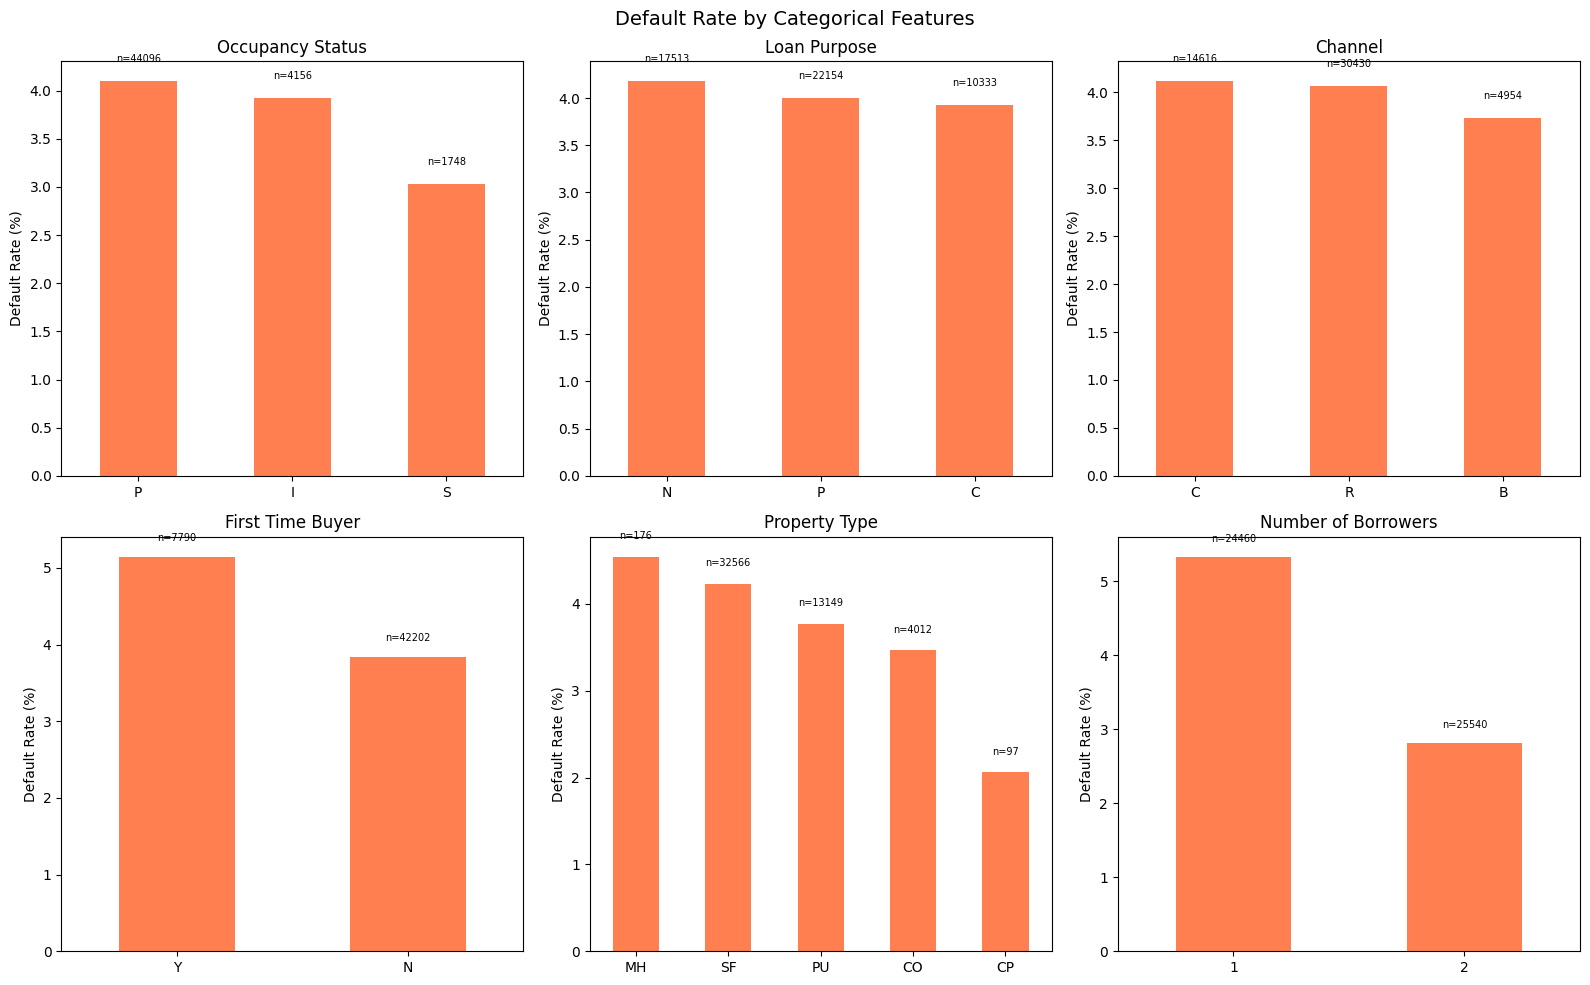

In [18]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Default Rate by Categorical Features', fontsize=14)

cat_features = [
    ('occupancy_status', 'Occupancy Status'),
    ('loan_purpose', 'Loan Purpose'),
    ('channel', 'Channel'),
    ('first_time_buyer', 'First Time Buyer'),
    ('property_type', 'Property Type'),
    ('num_borrowers', 'Number of Borrowers')
]

for idx, (col, title) in enumerate(cat_features):
    ax = axes[idx // 3][idx % 3]
    
    default_rates = model_clean.groupby(col)['default_flag'].mean() * 100
    counts = model_clean[col].value_counts()
    
    default_rates.sort_values(ascending=False).plot(kind='bar', ax=ax, color='coral')
    ax.set_title(title)
    ax.set_ylabel('Default Rate (%)')
    ax.set_xlabel('')
    
    # Show sample size on top of each bar
    for i, (category, rate) in enumerate(default_rates.sort_values(ascending=False).items()):
        ax.text(i, rate + 0.2, f'n={counts[category]}', ha='center', fontsize=7)
    
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### 5.3 Correlation Analysis

Negative correlations (lower value = more default):
credit_score       -0.1397
num_borrowers      -0.0639
postal_code        -0.0322
orig_upb           -0.0051
msa                -0.0041
super_conforming   -0.0039
num_units           0.0194
orig_loan_term      0.0299
mi_pct              0.0341
orig_ltv            0.0497
Name: default_flag, dtype: float64

Positive correlations (higher value = more default):
msa                     -0.0041
super_conforming        -0.0039
num_units                0.0194
orig_loan_term           0.0299
mi_pct                   0.0341
orig_ltv                 0.0497
orig_cltv                0.0545
relief_refi_indicator    0.0588
orig_dti                 0.0681
orig_interest_rate       0.0794
Name: default_flag, dtype: float64


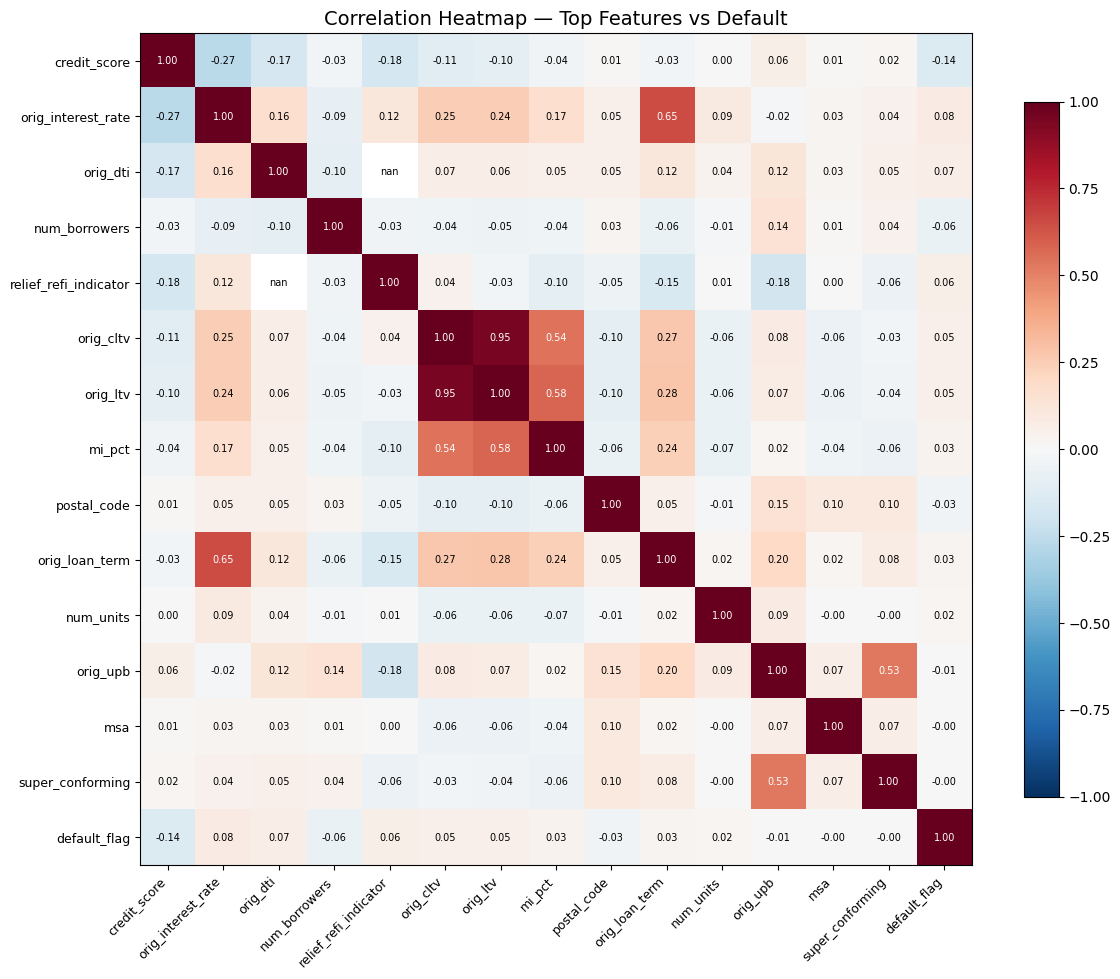

In [19]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

# Check which numeric features correlate most with default
numeric_cols = model_clean.select_dtypes(include=[np.number]).columns.tolist()
target_corr = model_clean[numeric_cols].corr()['default_flag'].drop('default_flag').sort_values()

print("Negative correlations (lower value = more default):")
print(target_corr.head(10).round(4))
print("\nPositive correlations (higher value = more default):")
print(target_corr.tail(10).round(4))

# Heatmap of the top 15 features by correlation strength
top_features = target_corr.abs().sort_values(ascending=False).head(15).index.tolist()
top_features.append('default_flag')

fig, ax = plt.subplots(figsize=(12, 10))
corr_matrix = model_clean[top_features].corr()

im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1)

ax.set_xticks(range(len(top_features)))
ax.set_yticks(range(len(top_features)))
ax.set_xticklabels(top_features, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(top_features, fontsize=9)

for i in range(len(top_features)):
    for j in range(len(top_features)):
        val = corr_matrix.iloc[i, j]
        color = 'white' if abs(val) > 0.5 else 'black'
        ax.text(j, i, '{:.2f}'.format(val), ha='center', va='center', fontsize=7, color=color)

plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_title('Correlation Heatmap — Top Features vs Default', fontsize=14)
plt.tight_layout()
plt.show()

## 7. Feature Engineering
### 7.1 Origination-Based Features

In [ ]:
# Feature Engineering

# Credit score tiers based on common underwriting buckets
def fico_tier(score):
    if pd.isna(score):
        return 'Unknown'
    elif score < 620:
        return 'Subprime'
    elif score < 680:
        return 'Near_Prime'
    elif score < 740:
        return 'Prime'
    else:
        return 'Super_Prime'

model_clean['fico_tier'] = model_clean['credit_score'].apply(fico_tier)

# Binary flags for high-risk conditions
model_clean['high_ltv'] = (model_clean['orig_ltv'] > 80).astype(int)
model_clean['high_dti'] = (model_clean['orig_dti'] > 43).astype(int)
model_clean['low_fico'] = (model_clean['credit_score'] < 680).astype(int)
model_clean['high_rate'] = (model_clean['orig_interest_rate'] > 4.5).astype(int)

# Interaction features — combining two risk factors together
model_clean['low_fico_high_ltv'] = (model_clean['low_fico'] & model_clean['high_ltv']).astype(int)
model_clean['low_fico_high_dti'] = (model_clean['low_fico'] & model_clean['high_dti']).astype(int)

# Gap between CLTV and LTV — a large gap means there's secondary financing
model_clean['cltv_ltv_gap'] = model_clean['orig_cltv'] - model_clean['orig_ltv']

# Loan term buckets
def loan_term_bucket(term):
    if term <= 180:
        return '15yr_or_less'
    elif term <= 240:
        return '20yr'
    else:
        return '30yr'

model_clean['loan_term_bucket'] = model_clean['orig_loan_term'].apply(loan_term_bucket)

# Check the new features
new_features = ['fico_tier', 'high_ltv', 'high_dti', 'low_fico', 'high_rate',
                'low_fico_high_ltv', 'low_fico_high_dti', 'cltv_ltv_gap', 'loan_term_bucket']

print("Shape:", model_clean.shape)
for col in new_features:
    print("\n" + col)
    print(model_clean[col].value_counts())

Shape: (50000, 31)

fico_tier
fico_tier
Super_Prime    31609
Prime          14017
Near_Prime      4015
Subprime         359
Name: count, dtype: int64

high_ltv
high_ltv
0    37156
1    12844
Name: count, dtype: int64

high_dti
high_dti
0    42246
1     7754
Name: count, dtype: int64

low_fico
low_fico
0    45626
1     4374
Name: count, dtype: int64

high_rate
high_rate
0    45387
1     4613
Name: count, dtype: int64

low_fico_high_ltv
low_fico_high_ltv
0    48879
1     1121
Name: count, dtype: int64

low_fico_high_dti
low_fico_high_dti
0    49392
1      608
Name: count, dtype: int64

cltv_ltv_gap
cltv_ltv_gap
0.0      47073
10.0       357
15.0       215
5.0        145
8.0        133
         ...  
82.0         1
81.0         1
64.0         1
77.0         1
809.0        1
Name: count, Length: 77, dtype: int64

loan_term_bucket
loan_term_bucket
30yr            37102
15yr_or_less    10278
20yr             2620
Name: count, dtype: int64


In [21]:
# Check if the engineered features actually separate default risk

eng_features = ['fico_tier', 'high_ltv', 'high_dti', 'low_fico', 'high_rate',
                'low_fico_high_ltv', 'low_fico_high_dti', 'loan_term_bucket']

for col in eng_features:
    rates = model_clean.groupby(col)['default_flag'].agg(['mean', 'count'])
    rates['mean'] = (rates['mean'] * 100).round(2)
    rates.columns = ['default_rate_%', 'loan_count']
    print(col)
    print(rates.sort_values('default_rate_%', ascending=False))
    print()

fico_tier
             default_rate_%  loan_count
fico_tier                              
Subprime              14.21         359
Near_Prime            10.54        4015
Prime                  5.70       14017
Super_Prime            2.38       31609

high_ltv
          default_rate_%  loan_count
high_ltv                            
1                   5.69       12844
0                   3.48       37156

high_dti
          default_rate_%  loan_count
high_dti                            
1                   5.27        7754
0                   3.82       42246

low_fico
          default_rate_%  loan_count
low_fico                            
1                  10.84        4374
0                   3.40       45626

high_rate
           default_rate_%  loan_count
high_rate                            
1                    7.63        4613
0                    3.68       45387

low_fico_high_ltv
                   default_rate_%  loan_count
low_fico_high_ltv                            
1 

In [22]:
# Check which columns are categorical and how many unique values they have
cat_cols = model_clean.select_dtypes(include='object').columns.tolist()

for col in cat_cols:
    print(col, "->", model_clean[col].nunique(), "unique values")

first_time_buyer -> 2 unique values
occupancy_status -> 3 unique values
channel -> 3 unique values
property_state -> 54 unique values
property_type -> 5 unique values
loan_purpose -> 3 unique values
mi_cancel_indicator -> 3 unique values
fico_tier -> 4 unique values
loan_term_bucket -> 3 unique values


In [23]:
# Map each state to a US Census region to reduce the number of categories

state_to_region = {
    'CT': 'Northeast', 'ME': 'Northeast', 'MA': 'Northeast', 'NH': 'Northeast',
    'RI': 'Northeast', 'VT': 'Northeast', 'NJ': 'Northeast', 'NY': 'Northeast', 'PA': 'Northeast',
    'AL': 'Southeast', 'AR': 'Southeast', 'DE': 'Southeast', 'FL': 'Southeast',
    'GA': 'Southeast', 'KY': 'Southeast', 'LA': 'Southeast', 'MD': 'Southeast',
    'MS': 'Southeast', 'NC': 'Southeast', 'OK': 'Southeast', 'SC': 'Southeast',
    'TN': 'Southeast', 'TX': 'Southeast', 'VA': 'Southeast', 'WV': 'Southeast', 'DC': 'Southeast',
    'IL': 'Midwest', 'IN': 'Midwest', 'IA': 'Midwest', 'KS': 'Midwest',
    'MI': 'Midwest', 'MN': 'Midwest', 'MO': 'Midwest', 'NE': 'Midwest',
    'ND': 'Midwest', 'OH': 'Midwest', 'SD': 'Midwest', 'WI': 'Midwest',
    'AZ': 'West', 'CO': 'West', 'ID': 'West', 'MT': 'West', 'NV': 'West',
    'NM': 'West', 'UT': 'West', 'WY': 'West',
    'AK': 'Pacific', 'CA': 'Pacific', 'HI': 'Pacific', 'OR': 'Pacific', 'WA': 'Pacific',
    'GU': 'Territory', 'PR': 'Territory', 'VI': 'Territory'
}

model_clean['region'] = model_clean['property_state'].map(state_to_region)

# Check if any states didn't get mapped
unmapped = model_clean[model_clean['region'].isna()]['property_state'].unique()
if len(unmapped) > 0:
    print("Unmapped states:", unmapped)
else:
    print("All states mapped successfully")

print("\nRegion distribution:")
print(model_clean['region'].value_counts())

# Drop state, postal code, and MSA since we now have region instead
model_clean = model_clean.drop(columns=['property_state', 'postal_code', 'msa'])
print("\nShape after geographic cleanup:", model_clean.shape)

All states mapped successfully

Region distribution:
region
Southeast    16054
Midwest      11386
Pacific      10683
Northeast     6690
West          5169
Territory       18
Name: count, dtype: int64

Shape after geographic cleanup: (50000, 29)


### 7.2 Behavioral Features from Performance Data

In [ ]:
# Explore the performance file before creating features from it
perf_early = perf[perf['loan_age'] <= 11].copy()
perf_early['delinq_numeric'] = pd.to_numeric(
    perf_early['delinquency_status'].replace('RA', '999'), errors='coerce')

print("Records in first 12 months:", len(perf_early))
print("Unique loans:", perf_early['loan_seq_no'].nunique())

worst_early = perf_early.groupby('loan_seq_no')['delinq_numeric'].max()
print("\nWorst delinquency in first 12 months:")
print("  Never late:     ", (worst_early == 0).sum())
print("  Hit 30 days:    ", (worst_early == 1).sum())
print("  Hit 60 days:    ", (worst_early == 2).sum())
print("  Hit 90+ days:   ", (worst_early >= 3).sum())

mod_count = perf_early[perf_early['modification_flag'].isin(['Y', 'P'])]['loan_seq_no'].nunique()
print("\nLoans modified in first 12 months:", mod_count)

upb_by_loan = perf_early.groupby('loan_seq_no')['current_upb'].agg(['first', 'last'])
upb_by_loan['paydown_pct'] = (upb_by_loan['first'] - upb_by_loan['last']) / upb_by_loan['first']
print("\nBalance paydown ratio in first 12 months:")
print(upb_by_loan['paydown_pct'].describe().round(4))

months_per_loan = perf_early.groupby('loan_seq_no')['loan_age'].count()
print("\nMonths of data per loan:")
print(months_per_loan.describe().round(2))

rate_change = perf_early.groupby('loan_seq_no')['current_interest_rate'].agg(lambda x: x.max() - x.min())
print("\nLoans with interest rate change:", (rate_change > 0).sum())

Records in first 12 months: 571311
Unique loans: 48560

Worst delinquency in first 12 months:
  Never late:      47352
  Hit 30 days:     967
  Hit 60 days:     108
  Hit 90+ days:    133

Loans modified in first 12 months: 461

Balance paydown ratio in first 12 months:
count    48539.0000
mean         0.0865
std          0.2296
min         -0.8949
25%          0.0154
50%          0.0178
75%          0.0450
max          1.0000
Name: paydown_pct, dtype: float64

Months of data per loan:
count    48560.00
mean        11.77
std          1.60
min          1.00
25%         12.00
50%         12.00
75%         12.00
max         46.00
Name: loan_age, dtype: float64

Loans with interest rate change: 122


In [25]:
# Now create the actual behavioral features from the early performance data

behavioral = perf_early.groupby('loan_seq_no').agg(
    max_delinq_12m=('delinq_numeric', 'max'),
    ever_30dpd_12m=('delinq_numeric', lambda x: int((x >= 1).any())),
    ever_60dpd_12m=('delinq_numeric', lambda x: int((x >= 2).any())),
    count_delinq_months=('delinq_numeric', lambda x: int((x >= 1).sum())),
    months_observed=('loan_age', 'count'),
    first_upb=('current_upb', 'first'),
    last_upb_12m=('current_upb', 'last'),
    was_modified_12m=('modification_flag', lambda x: int(x.isin(['Y', 'P']).any())),
    rate_change_12m=('current_interest_rate', lambda x: x.max() - x.min()),
).reset_index()

behavioral['upb_paydown_ratio'] = (
    (behavioral['first_upb'] - behavioral['last_upb_12m']) / behavioral['first_upb']
).fillna(0)

behavioral = behavioral.merge(orig[['loan_seq_no', 'orig_dti']], on='loan_seq_no', how='left')
behavioral['dti_missing'] = (behavioral['orig_dti'].isna() | (behavioral['orig_dti'] == 999)).astype(int)
behavioral = behavioral.drop(columns=['orig_dti'])

print("Behavioral features created for", len(behavioral), "loans")
print(behavioral.describe().round(3))

Behavioral features created for 48560 loans
       max_delinq_12m  ever_30dpd_12m  ever_60dpd_12m  count_delinq_months  \
count       48560.000       48560.000       48560.000             48560.00   
mean            0.060           0.025           0.005                 0.06   
std             4.548           0.156           0.070                 0.61   
min             0.000           0.000           0.000                 0.00   
25%             0.000           0.000           0.000                 0.00   
50%             0.000           0.000           0.000                 0.00   
75%             0.000           0.000           0.000                 0.00   
max           999.000           1.000           1.000                24.00   

       months_observed   first_upb  last_upb_12m  was_modified_12m  \
count        48560.000   48560.000     48560.000         48560.000   
mean            11.765  221746.528    200138.841             0.009   
std              1.598  119006.236    12202

In [26]:
# Merge behavioral features with origination data
# Use left join so we keep all 50,000 loans even if some have no early performance data

if 'max_delinq_12m' not in model_clean.columns:
    model_clean['loan_seq_no'] = loan_ids
    model_clean = model_clean.merge(behavioral, on='loan_seq_no', how='left')

    fill_zeros = ['max_delinq_12m', 'ever_30dpd_12m', 'ever_60dpd_12m', 
                  'count_delinq_months', 'months_observed', 'was_modified_12m',
                  'rate_change_12m', 'dti_missing', 'upb_paydown_ratio']

    for col in fill_zeros:
        model_clean[col] = model_clean[col].fillna(0)

    loan_ids = model_clean['loan_seq_no'].copy()
    model_clean = model_clean.drop(columns=['loan_seq_no'])

print("Shape after merge:", model_clean.shape)
print("Missing in first_upb:", model_clean['first_upb'].isna().sum())
print("Missing in last_upb_12m:", model_clean['last_upb_12m'].isna().sum())

Shape after merge: (50000, 40)
Missing in first_upb: 1440
Missing in last_upb_12m: 1440


                     Non_Default  Default    Ratio
max_delinq_12m            0.0188   0.9990    53.25
ever_30dpd_12m            0.0171   0.1907    11.13
ever_60dpd_12m            0.0012   0.0914    78.31
count_delinq_months       0.0247   0.8552    34.60
months_observed          11.3149  14.0652     1.24
was_modified_12m          0.0002   0.2223   969.69
rate_change_12m           0.0000   0.0569  1559.69
upb_paydown_ratio         0.0855   0.0477     0.56
dti_missing               0.0771   0.1581     2.05


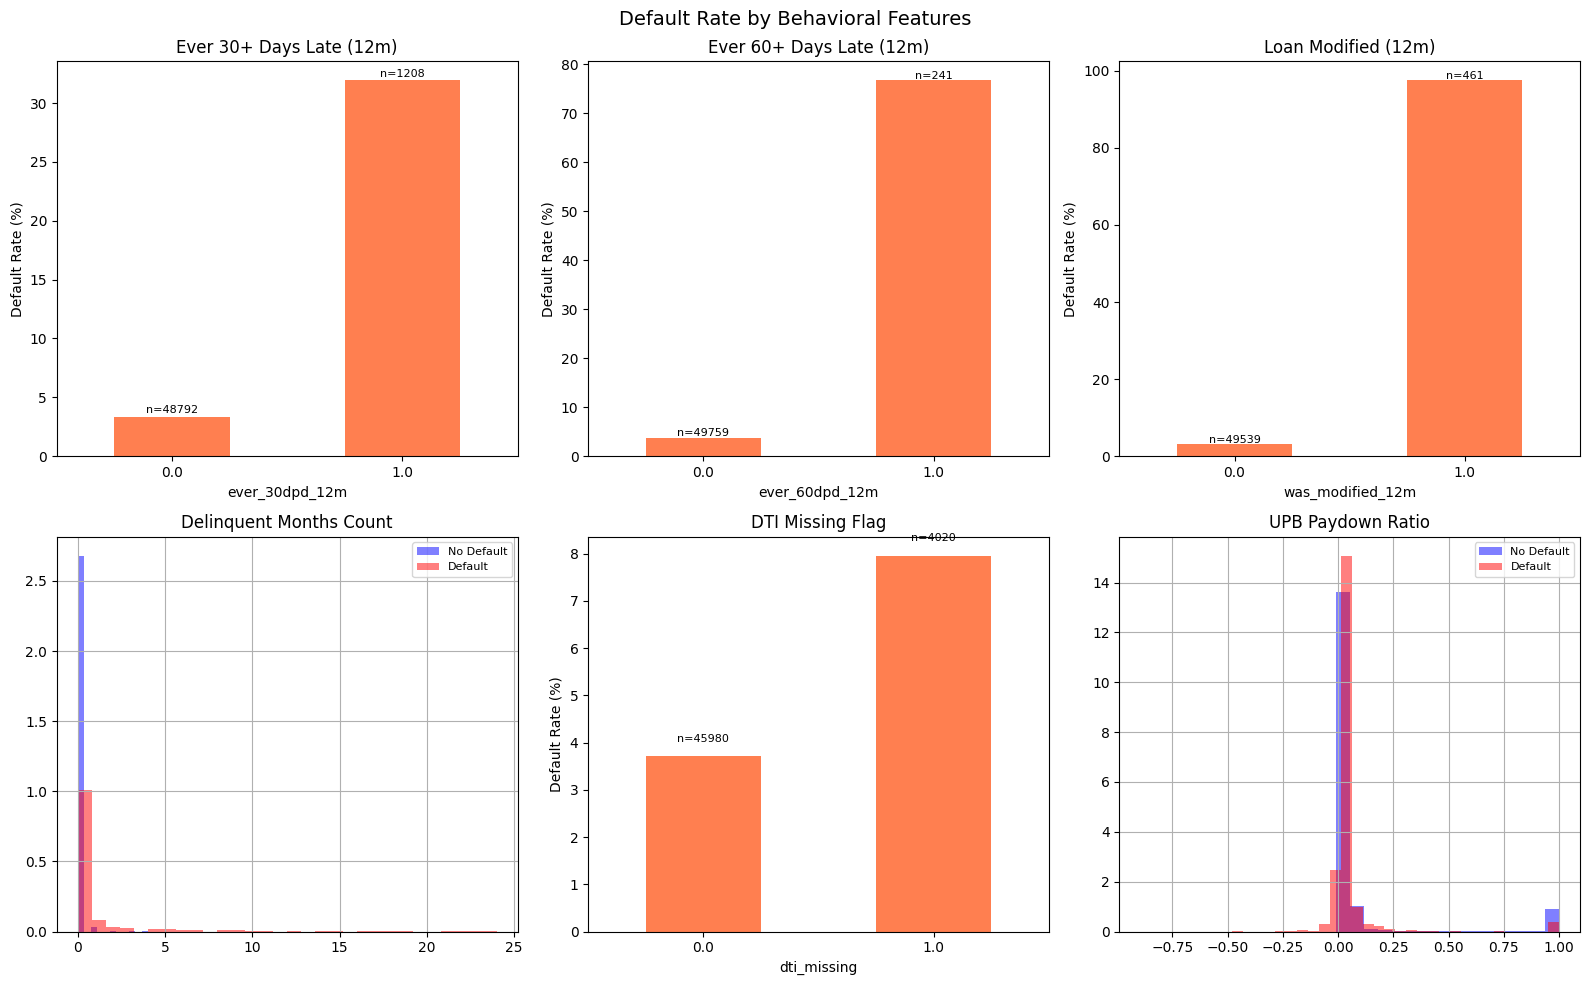

In [27]:
# Compare behavioral features between defaulted and non-defaulted loans

beh_features = ['max_delinq_12m', 'ever_30dpd_12m', 'ever_60dpd_12m', 
                'count_delinq_months', 'months_observed', 'was_modified_12m',
                'rate_change_12m', 'upb_paydown_ratio', 'dti_missing']

comparison = model_clean.groupby('default_flag')[beh_features].mean().T
comparison.columns = ['Non_Default', 'Default']
comparison['Ratio'] = (comparison['Default'] / comparison['Non_Default']).round(2)
print(comparison.round(4))

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Default Rate by Behavioral Features', fontsize=14)

plot_features = [
    ('ever_30dpd_12m', 'Ever 30+ Days Late (12m)'),
    ('ever_60dpd_12m', 'Ever 60+ Days Late (12m)'),
    ('was_modified_12m', 'Loan Modified (12m)'),
    ('count_delinq_months', 'Delinquent Months Count'),
    ('dti_missing', 'DTI Missing Flag'),
    ('upb_paydown_ratio', 'UPB Paydown Ratio')
]

for idx, (col, title) in enumerate(plot_features):
    ax = axes[idx // 3][idx % 3]
    
    if model_clean[col].nunique() <= 5:
        rates = model_clean.groupby(col)['default_flag'].agg(['mean', 'count'])
        rates['mean'] = (rates['mean'] * 100).round(2)
        rates['mean'].plot(kind='bar', ax=ax, color='coral')
        ax.set_ylabel('Default Rate (%)')
        ax.set_title(title)
        ax.tick_params(axis='x', rotation=0)
        for i, (category, row) in enumerate(rates.iterrows()):
            ax.text(i, row['mean'] + 0.3, f"n={int(row['count'])}", ha='center', fontsize=8)
    else:
        model_clean[model_clean['default_flag'] == 0][col].dropna().hist(
            bins=30, alpha=0.5, label='No Default', ax=ax, color='blue', density=True)
        model_clean[model_clean['default_flag'] == 1][col].dropna().hist(
            bins=30, alpha=0.5, label='Default', ax=ax, color='red', density=True)
        ax.set_title(title)
        ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 8. Data Preparation and Encoding

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

# One-hot encode categorical columns
cat_to_encode = ['first_time_buyer', 'occupancy_status', 'channel', 'property_type',
                 'loan_purpose', 'mi_cancel_indicator', 'fico_tier', 'loan_term_bucket', 'region']

model_encoded = pd.get_dummies(model_clean, columns=cat_to_encode, drop_first=True)

X = model_encoded.drop(columns=['default_flag'])
y = model_encoded['default_flag']

# 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

imputer = SimpleImputer(strategy='median')
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test_imp = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

print("Train:", X_train.shape[0], "loans | Default rate: {:.2f}%".format(y_train.mean()*100))
print("Test:", X_test.shape[0], "loans | Default rate: {:.2f}%".format(y_test.mean()*100))
print("Total features:", X.shape[1])

Train: 40000 loans | Default rate: 4.05%
Test: 10000 loans | Default rate: 4.05%
Total features: 53


## 9. Model Training and Evaluation

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score
import warnings
warnings.filterwarnings('ignore')

results = {}
probas = {}

# Logistic Regression
print("Tuning Logistic Regression...")
lr_grid = GridSearchCV(
    Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    param_grid={'model__C': [0.01, 0.1, 1, 10],
                'model__class_weight': [None, 'balanced']},
    scoring='roc_auc', cv=5, n_jobs=-1
)
lr_grid.fit(X_train_imp, y_train)
probas['Logistic Regression'] = lr_grid.best_estimator_.predict_proba(X_test_imp)[:, 1]
results['Logistic Regression'] = roc_auc_score(y_test, probas['Logistic Regression'])
print("AUC:", round(results['Logistic Regression'], 4), "| Best:", lr_grid.best_params_)

# Decision Tree
print("\nTuning Decision Tree...")
dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid={'max_depth': [5, 8, 10, 15],
                'min_samples_leaf': [10, 20, 50],
                'class_weight': [None, 'balanced']},
    scoring='roc_auc', cv=5, n_jobs=-1
)
dt_grid.fit(X_train_imp, y_train)
probas['Decision Tree'] = dt_grid.best_estimator_.predict_proba(X_test_imp)[:, 1]
results['Decision Tree'] = roc_auc_score(y_test, probas['Decision Tree'])
print("AUC:", round(results['Decision Tree'], 4), "| Best:", dt_grid.best_params_)

# Random Forest
print("\nTuning Random Forest...")
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid={'n_estimators': [200, 300],
                'max_depth': [10, 15, 20],
                'min_samples_leaf': [10, 20],
                'class_weight': [None, 'balanced']},
    scoring='roc_auc', cv=5, n_jobs=-1
)
rf_grid.fit(X_train_imp, y_train)
probas['Random Forest'] = rf_grid.best_estimator_.predict_proba(X_test_imp)[:, 1]
results['Random Forest'] = roc_auc_score(y_test, probas['Random Forest'])
print("AUC:", round(results['Random Forest'], 4), "| Best:", rf_grid.best_params_)

# XGBoost
print("\nTuning XGBoost...")
xgb_grid = GridSearchCV(
    XGBClassifier(eval_metric='auc', random_state=42, use_label_encoder=False, n_jobs=-1),
    param_grid={'n_estimators': [200, 400],
                'max_depth': [3, 5],
                'learning_rate': [0.01, 0.05],
                'scale_pos_weight': [1, 5, 15],
                'min_child_weight': [5, 10]},
    scoring='roc_auc', cv=5, n_jobs=-1
)
xgb_grid.fit(X_train_imp, y_train)
probas['XGBoost'] = xgb_grid.best_estimator_.predict_proba(X_test_imp)[:, 1]
results['XGBoost'] = roc_auc_score(y_test, probas['XGBoost'])
print("AUC:", round(results['XGBoost'], 4), "| Best:", xgb_grid.best_params_)

# Compare all models
print("\nModel Comparison:")
for name, auc in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(" ", name, "-", round(auc, 4))

Tuning Logistic Regression...
AUC: 0.8071 | Best: {'model__C': 10, 'model__class_weight': 'balanced'}

Tuning Decision Tree...
AUC: 0.7532 | Best: {'class_weight': 'balanced', 'max_depth': 5, 'min_samples_leaf': 50}

Tuning Random Forest...
AUC: 0.8049 | Best: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_leaf': 20, 'n_estimators': 200}

Tuning XGBoost...
AUC: 0.8107 | Best: {'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 10, 'n_estimators': 200, 'scale_pos_weight': 15}

Model Comparison:
  XGBoost - 0.8107
  Logistic Regression - 0.8071
  Random Forest - 0.8049
  Decision Tree - 0.7532


In [30]:
# Robustness check: was_modified_12m, Drop was_modified_12m and retrain XGBoost
X_train_no_mod = X_train_imp.drop(columns=['was_modified_12m'])
X_test_no_mod = X_test_imp.drop(columns=['was_modified_12m'])

xgb_no_mod = XGBClassifier(**xgb_grid.best_params_, 
                            eval_metric='auc', random_state=42, 
                            use_label_encoder=False, n_jobs=-1)
xgb_no_mod.fit(X_train_no_mod, y_train)

y_proba_no_mod = xgb_no_mod.predict_proba(X_test_no_mod)[:, 1]
auc_no_mod = roc_auc_score(y_test, y_proba_no_mod)

print(f"XGBoost WITH was_modified_12m:    AUC = {results['XGBoost']:.4f}")
print(f"XGBoost WITHOUT was_modified_12m: AUC = {auc_no_mod:.4f}")
print(f"Difference:                       {results['XGBoost'] - auc_no_mod:+.4f}")
print(f"\nConclusion: The model {'retains strong performance' if auc_no_mod > 0.78 else 'loses significant performance'} "
      f"even without the modification flag, confirming that other features "
      f"(credit_score, upb_paydown_ratio, num_borrowers, orig_dti) "
      f"carry substantial independent predictive power.")

XGBoost WITH was_modified_12m:    AUC = 0.8107
XGBoost WITHOUT was_modified_12m: AUC = 0.8073
Difference:                       +0.0033

Conclusion: The model retains strong performance even without the modification flag, confirming that other features (credit_score, upb_paydown_ratio, num_borrowers, orig_dti) carry substantial independent predictive power.


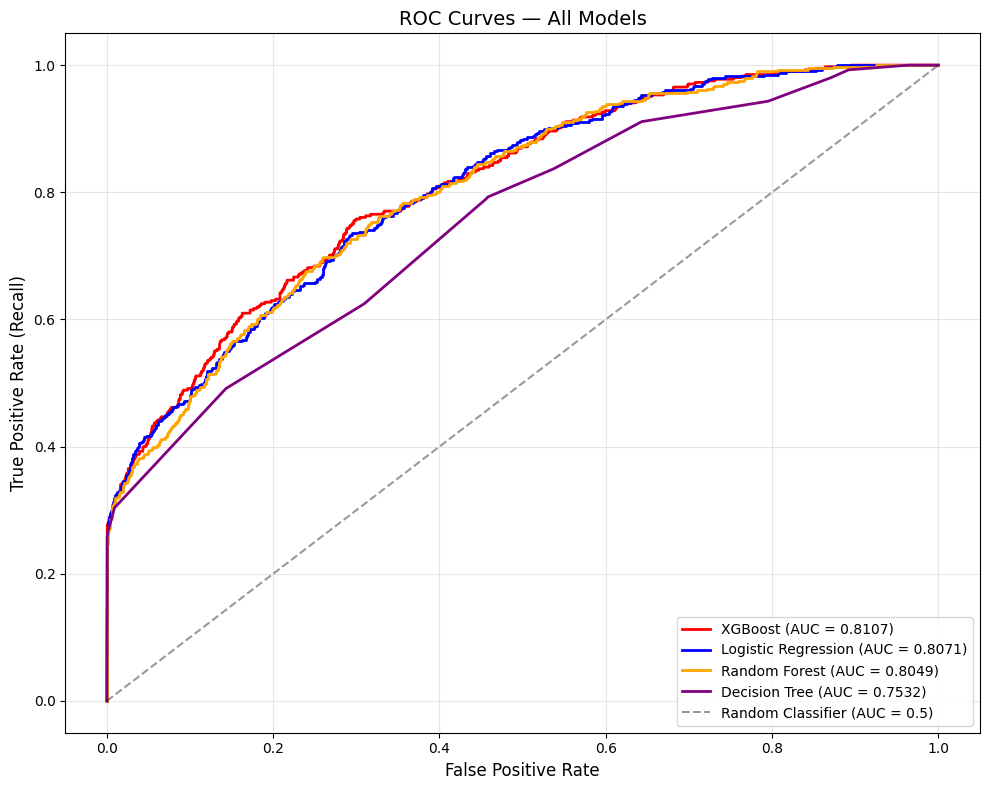

In [31]:
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(10, 8))

colors = {'XGBoost': 'red', 'Logistic Regression': 'blue',
          'Random Forest': 'orange', 'Decision Tree': 'purple'}

for name in sorted(results, key=results.get, reverse=True):
    fpr, tpr, _ = roc_curve(y_test, probas[name])
    ax.plot(fpr, tpr, label='{} (AUC = {:.4f})'.format(name, results[name]),
            color=colors[name], linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random Classifier (AUC = 0.5)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title('ROC Curves — All Models', fontsize=14)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

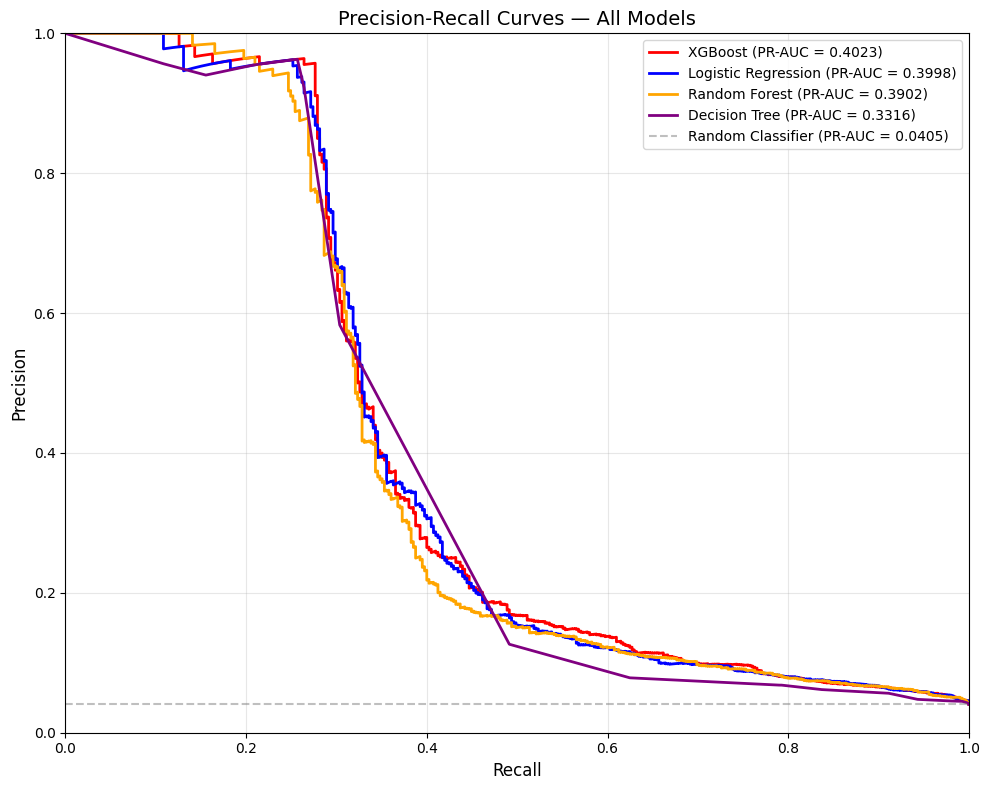

In [32]:
from sklearn.metrics import precision_recall_curve, average_precision_score

fig, ax = plt.subplots(figsize=(10, 8))

colors = {'XGBoost': 'red', 'Logistic Regression': 'blue',
          'Random Forest': 'orange', 'Decision Tree': 'purple'}

for name in sorted(results, key=results.get, reverse=True):
    precision, recall, _ = precision_recall_curve(y_test, probas[name])
    pr_auc = average_precision_score(y_test, probas[name])
    ax.plot(recall, precision, label='{} (PR-AUC = {:.4f})'.format(name, pr_auc),
            color=colors[name], linewidth=2)

baseline = y_test.mean()
ax.axhline(y=baseline, color='gray', linestyle='--', alpha=0.5,
           label='Random Classifier (PR-AUC = {:.4f})'.format(baseline))

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves — All Models', fontsize=14)
ax.legend(loc='upper right', fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Model Interpretability (SHAP)


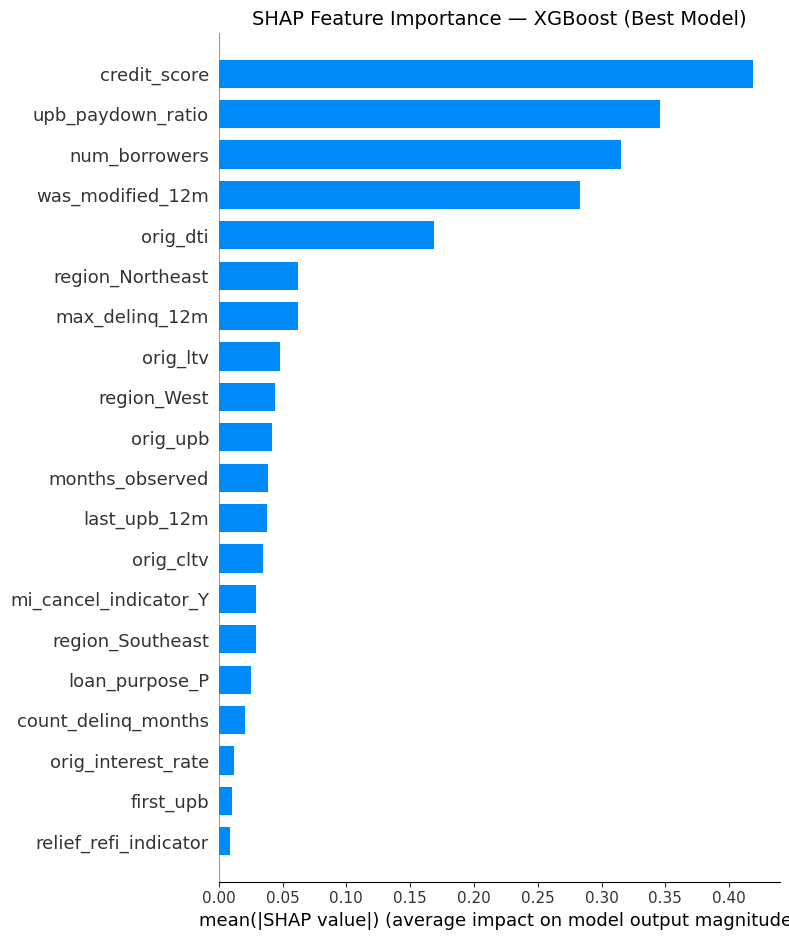

In [33]:
import shap

# SHAP analysis on the best XGBoost model
best_xgb = xgb_grid.best_estimator_
explainer = shap.TreeExplainer(best_xgb)

# Use a sample of 2000 loans to keep it manageable
X_shap_sample = X_test_imp.sample(n=2000, random_state=42)
shap_values = explainer.shap_values(X_shap_sample)

plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values, X_shap_sample, plot_type="bar", show=False, max_display=20)
plt.title("SHAP Feature Importance — XGBoost (Best Model)", fontsize=14)
plt.tight_layout()
plt.show()

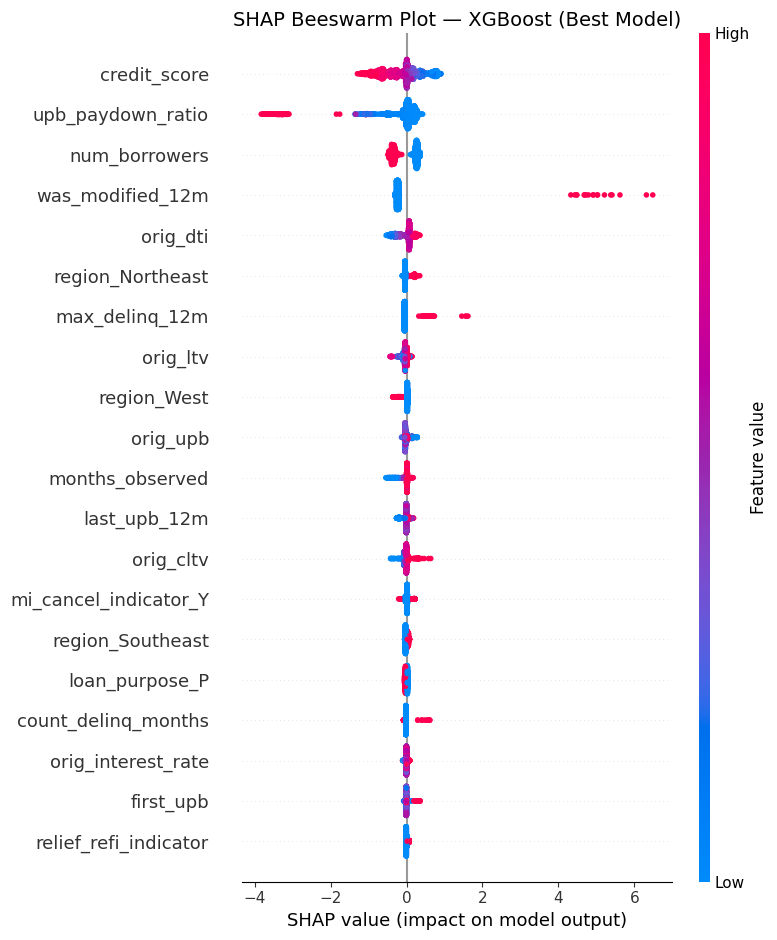

In [34]:
# Beeswarm plot shows direction of each feature's effect on predictions
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values, X_shap_sample, show=False, max_display=20)
plt.title("SHAP Beeswarm Plot — XGBoost (Best Model)", fontsize=14)
plt.tight_layout()
plt.show()

## 11. Threshold Optimization

In [35]:
from sklearn.metrics import roc_curve, classification_report, confusion_matrix

# Find best threshold using Youden's J statistic
fpr, tpr, thresholds = roc_curve(y_test, probas['XGBoost'])
best_threshold = thresholds[(tpr - fpr).argmax()]

y_pred_default = (probas['XGBoost'] >= 0.50).astype(int)
y_pred_optimized = (probas['XGBoost'] >= best_threshold).astype(int)

print("Default threshold: 0.50")
print("Optimized threshold:", round(best_threshold, 4))

# Compare the two thresholds
print("\nWith threshold 0.50:")
print(classification_report(y_test, y_pred_default, target_names=['No Default', 'Default']))
cm1 = confusion_matrix(y_test, y_pred_default)
print(cm1)
print("Caught {} out of {} defaults".format(cm1[1][1], cm1[1].sum()))

print("\nWith threshold", round(best_threshold, 4))
print(classification_report(y_test, y_pred_optimized, target_names=['No Default', 'Default']))
cm2 = confusion_matrix(y_test, y_pred_optimized)
print(cm2)
print("Caught {} out of {} defaults".format(cm2[1][1], cm2[1].sum()))

Default threshold: 0.50
Optimized threshold: 0.3631

With threshold 0.50:
              precision    recall  f1-score   support

  No Default       0.98      0.91      0.94      9595
     Default       0.18      0.49      0.27       405

    accuracy                           0.89     10000
   macro avg       0.58      0.70      0.60     10000
weighted avg       0.94      0.89      0.91     10000

[[8711  884]
 [ 207  198]]
Caught 198 out of 405 defaults

With threshold 0.3631
              precision    recall  f1-score   support

  No Default       0.99      0.70      0.82      9595
     Default       0.10      0.76      0.17       405

    accuracy                           0.70     10000
   macro avg       0.54      0.73      0.50     10000
weighted avg       0.95      0.70      0.79     10000

[[6744 2851]
 [  99  306]]
Caught 306 out of 405 defaults


## 12. Summary and Conclusions

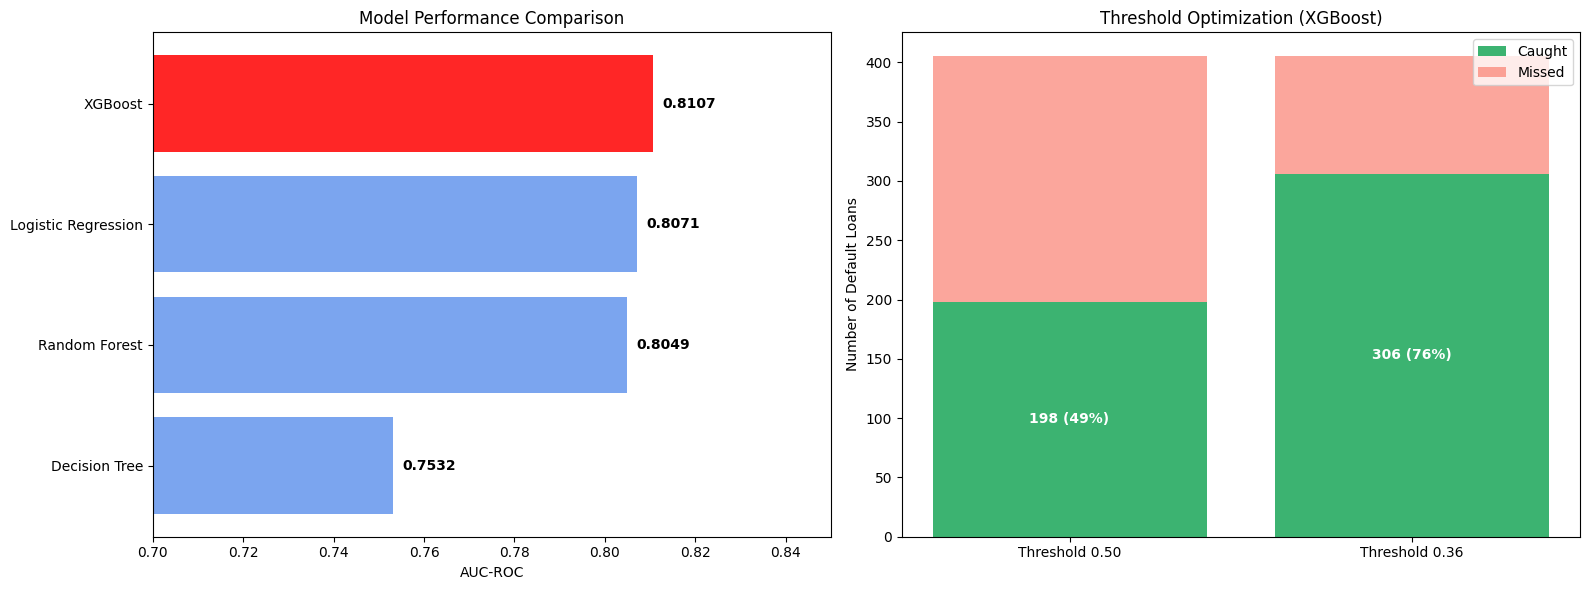


Summary:
Dataset: Freddie Mac 2015, 50,000 loans, 4.05% default rate
Best model: XGBoost with AUC of 0.8107
Lowering threshold from 0.50 to 0.36 caught 76% of defaults instead of 49%


In [36]:
# Model comparison and threshold impact side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left: AUC scores for all models
sorted_models = sorted(results.items(), key=lambda x: x[1])
names = [m[0] for m in sorted_models]
scores = [m[1] for m in sorted_models]
colors = ['red' if n == 'XGBoost' else 'cornflowerblue' for n in names]

bars = ax1.barh(names, scores, color=colors, alpha=0.85)
ax1.set_xlabel('AUC-ROC')
ax1.set_title('Model Performance Comparison')
ax1.set_xlim(0.7, 0.85)
for bar, score in zip(bars, scores):
    ax1.text(score + 0.002, bar.get_y() + bar.get_height()/2,
             round(score, 4), va='center', fontweight='bold')

# Right: how many defaults we catch at each threshold
cm1 = confusion_matrix(y_test, y_pred_default)
cm2 = confusion_matrix(y_test, y_pred_optimized)

total = cm1[1].sum()
caught = [cm1[1][1], cm2[1][1]]
missed = [cm1[1][0], cm2[1][0]]
labels = ['Threshold 0.50', 'Threshold {:.2f}'.format(best_threshold)]

ax2.bar(labels, caught, color='mediumseagreen', label='Caught')
ax2.bar(labels, missed, bottom=caught, color='salmon', alpha=0.7, label='Missed')
ax2.set_ylabel('Number of Default Loans')
ax2.set_title('Threshold Optimization (XGBoost)')
ax2.legend()

for i, c in enumerate(caught):
    ax2.text(i, c/2, '{} ({:.0f}%)'.format(c, c/total*100),
             ha='center', va='center', fontweight='bold', color='white')

plt.tight_layout()
plt.show()

print("\nSummary:")
print("Dataset: Freddie Mac 2015, 50,000 loans, {:.2f}% default rate".format(y.mean()*100))
print("Best model: XGBoost with AUC of", round(results['XGBoost'], 4))
print("Lowering threshold from 0.50 to {:.2f} caught {:.0f}% of defaults instead of {:.0f}%".format(
    best_threshold, caught[1]/total*100, caught[0]/total*100))